In [ ]:
# =========================
# 1. Google Drive + packages
# =========================
from google.colab import drive
drive.mount("/content/drive")

!pip -q install -U transformers scikit-image seaborn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 117.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.1 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [ ]:
# =========================
# 2. Imports + reproducibility
# =========================
import os
import re
import json
import random
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage as ndi

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerConfig, SegformerForSemanticSegmentation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from skimage import measure
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()


In [ ]:
# =========================
# 3. GPU verification
# =========================
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi

CUDA available: True
GPU count: 1
GPU: Tesla T4
Sat Sep 12 16:11:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |


In [ ]:
!unzip -q "/content/drive/MyDrive/brats.zip"

In [ ]:
# =========================
# 4. Dataset path
# =========================
DATA_PATH = "/content/BraTS2020_training_data/content/data"

# If your archive is not extracted yet, uncomment and adapt:
# !unzip -q "/content/drive/MyDrive/brats.zip" -d "/content/"

if not os.path.isdir(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_PATH}\n"
        "Extract your BraTS H5 dataset first and then rerun this cell."
    )

all_h5_files = sorted(
    f for f in os.listdir(DATA_PATH)
    if f.endswith(".h5")
)

print("H5 slices:", len(all_h5_files))
print("Examples:", all_h5_files[:5])

H5 slices: 57195
Examples: ['volume_100_slice_0.h5', 'volume_100_slice_1.h5', 'volume_100_slice_10.h5', 'volume_100_slice_100.h5', 'volume_100_slice_101.h5']


## 5. Patient/volume-level split

In [ ]:
def get_volume_id(filename):
    m = re.match(r"volume_(\d+)_slice_(\d+)\.h5", filename)
    return int(m.group(1)) if m else None

def mask_to_class_indices(mask):
    mask = np.asarray(mask)

    if mask.ndim == 2:
        return mask.astype(np.int64)

    if mask.ndim == 3:
        # HWC one-hot
        if mask.shape[-1] <= 5:
            return np.argmax(mask, axis=-1).astype(np.int64)

        # CHW one-hot
        if mask.shape[0] <= 5:
            return np.argmax(mask, axis=0).astype(np.int64)

    raise ValueError(f"Unsupported mask shape: {mask.shape}")


def scan_dataset(data_dir):
    records = []

    for filename in tqdm(
        sorted(os.listdir(data_dir)),
        desc="Scanning H5 dataset"
    ):
        if not filename.endswith(".h5"):
            continue

        volume = get_volume_id(filename)
        if volume is None:
            continue

        path = os.path.join(data_dir, filename)

        try:
            with h5py.File(path, "r") as h:
                mask = mask_to_class_indices(h["mask"][:])

            records.append({
                "file": filename,
                "volume": volume,
                "has_tumor": bool(np.any(mask > 0))
            })

        except Exception as e:
            print("Skipping unreadable file:", filename, e)

    return pd.DataFrame(records)


scan_df = scan_dataset(DATA_PATH)

print("Total slices:", len(scan_df))
print("Unique volumes:", scan_df["volume"].nunique())

Scanning H5 dataset:   0%|          | 0/57198 [00:00<?, ?it/s]

Total slices: 57195
Unique volumes: 369


In [ ]:
# =========================
# 6. Reproducible split
# =========================
volume_ids = scan_df["volume"].unique()

trainval_volumes, test_volumes = train_test_split(
    volume_ids,
    test_size=0.15,
    random_state=SEED
)

train_volumes, val_volumes = train_test_split(
    trainval_volumes,
    test_size=0.1765,
    random_state=SEED
)

train_df = scan_df[scan_df.volume.isin(train_volumes)].copy()
val_df   = scan_df[scan_df.volume.isin(val_volumes)].copy()
test_df  = scan_df[scan_df.volume.isin(test_volumes)].copy()


def build_file_list(df, empty_keep_frac=0.20, seed=SEED):
    rng = np.random.RandomState(seed)

    tumor = df[df.has_tumor]["file"].tolist()
    empty = df[~df.has_tumor]["file"].tolist()

    n_keep = int(round(empty_keep_frac * len(empty)))

    if n_keep:
        sampled_empty = rng.choice(
            empty,
            size=n_keep,
            replace=False
        ).tolist()
    else:
        sampled_empty = []

    return tumor + sampled_empty


train_files = build_file_list(train_df, seed=SEED)
val_files   = build_file_list(val_df, seed=SEED + 1)
test_files  = test_df["file"].tolist()


def volumes_from_files(files):
    return {get_volume_id(f) for f in files}


assert not (volumes_from_files(train_files) & volumes_from_files(val_files))
assert not (volumes_from_files(train_files) & volumes_from_files(test_files))
assert not (volumes_from_files(val_files) & volumes_from_files(test_files))

print(f"Train volumes: {len(train_volumes)} | slices used: {len(train_files)}")
print(f"Val volumes:   {len(val_volumes)} | slices used: {len(val_files)}")
print(f"Test volumes:  {len(test_volumes)} | slices used: {len(test_files)}")
print("Test set is full:", len(test_files) == len(test_df))
print("✅ Zero patient/volume overlap.")

Train volumes: 257 | slices used: 21657
Val volumes:   56 | slices used: 4642
Test volumes:  56 | slices used: 8680
Test set is full: True
✅ Zero patient/volume overlap.


## 7. Four-channel MRI preprocessing

In [ ]:
# NOTE: verify against your dataset's documentation which physical MRI
# sequence each of the 4 channels corresponds to (commonly T1, T1ce, T2,
# FLAIR for BraTS). Getting the channel order right matters if you ever
# swap datasets or compare against published BraTS baselines.
def prepare_4ch_image(image):
    image = np.asarray(image).astype(np.float32)

    # Convert to CHW.
    if image.ndim == 2:
        image = image[None, ...]

    elif image.ndim == 3:
        if image.shape[-1] in (1, 3, 4):
            image = np.transpose(image, (2, 0, 1))
        elif image.shape[0] in (1, 3, 4):
            pass
        else:
            raise ValueError(
                f"Cannot infer channel dimension from {image.shape}"
            )
    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")

    # The trained model expects exactly 4 channels.
    if image.shape[0] == 4:
        pass
    elif image.shape[0] == 3:
        # Fallback only for an unusual 3-channel file.
        image = np.concatenate(
            [image, image.mean(axis=0, keepdims=True)],
            axis=0
        )
    elif image.shape[0] == 1:
        image = np.repeat(image, 4, axis=0)
    else:
        raise ValueError(
            f"Expected 1, 3, or 4 channels, got {image.shape[0]}"
        )

    # Per-channel robust z-score, clipped to [-3, 3], mapped to [0, 1].
    out = np.zeros_like(image, dtype=np.float32)

    for c in range(4):
        x = image[c]

        finite = np.isfinite(x)
        nonzero = finite & (np.abs(x) > 0)

        vals = x[nonzero]

        if vals.size < 2:
            vals = x[finite]

        if vals.size < 2:
            continue

        mean = float(vals.mean())
        std = max(float(vals.std()), 1e-6)

        z = (x - mean) / std
        z = np.nan_to_num(
            z,
            nan=0.0,
            posinf=3.0,
            neginf=-3.0
        )
        z = np.clip(z, -3.0, 3.0)

        out[c] = (z + 3.0) / 6.0

    return out

In [ ]:
# =========================
# 8. Dataset
# =========================
def augment_pair(image, mask):
    """
    image: float32 array, shape (4, H, W), already normalized to [0, 1]
    mask:  int64 array, shape (H, W)

    Applies flips, small rotations, mild elastic deformation, and
    per-channel gamma jitter. All spatial transforms are applied
    identically to image and mask (mask always uses nearest-neighbor
    interpolation so label values stay integer).
    """
    # 1. Random horizontal / vertical flip
    if np.random.random() < 0.5:
        image = image[:, :, ::-1]
        mask = mask[:, ::-1]
    if np.random.random() < 0.5:
        image = image[:, ::-1, :]
        mask = mask[::-1, :]

    # 2. Random rotation (+/- 15 degrees)
    if np.random.random() < 0.5:
        angle = np.random.uniform(-15, 15)
        image = ndi.rotate(
            image, angle, axes=(1, 2), reshape=False,
            order=1, mode="nearest"
        )
        mask_f = ndi.rotate(
            mask.astype(np.float32), angle, axes=(0, 1),
            reshape=False, order=0, mode="nearest"
        )
        mask = np.round(mask_f).astype(np.int64)

    # 3. Mild elastic deformation (standard for medical-image segmentation)
    if np.random.random() < 0.3:
        h, w = mask.shape
        alpha, sigma = 20.0, 4.0

        dx = ndi.gaussian_filter(
            (np.random.random((h, w)) * 2 - 1), sigma
        ) * alpha
        dy = ndi.gaussian_filter(
            (np.random.random((h, w)) * 2 - 1), sigma
        ) * alpha

        yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
        coords_y = np.clip(yy + dy, 0, h - 1)
        coords_x = np.clip(xx + dx, 0, w - 1)

        deformed = np.zeros_like(image)
        for c in range(image.shape[0]):
            deformed[c] = ndi.map_coordinates(
                image[c], [coords_y, coords_x], order=1, mode="nearest"
            )
        image = deformed

        mask_f = ndi.map_coordinates(
            mask.astype(np.float32), [coords_y, coords_x],
            order=0, mode="nearest"
        )
        mask = np.round(mask_f).astype(np.int64)

    # 4. Per-channel gamma / intensity jitter (simulates scanner variability)
    if np.random.random() < 0.5:
        image = image.copy()
        for c in range(image.shape[0]):
            gamma = np.random.uniform(0.85, 1.15)
            image[c] = np.clip(image[c], 0.0, 1.0) ** gamma

    return np.ascontiguousarray(image), np.ascontiguousarray(mask)


def _worker_init_fn(worker_id):
    """Reseed numpy's global RNG per DataLoader worker so augmentation
    does not repeat identically across workers/epochs."""
    seed = (torch.initial_seed() + worker_id) % (2 ** 32)
    np.random.seed(seed)


class BraTSDataset(Dataset):
    def __init__(self, data_dir, file_list, augment=False):
        self.data_dir = data_dir
        self.file_list = list(file_list)
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        path = os.path.join(self.data_dir, filename)

        with h5py.File(path, "r") as h:
            image = prepare_4ch_image(h["image"][:])
            mask = mask_to_class_indices(h["mask"][:])

        if self.augment:
            image, mask = augment_pair(image, mask)

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).long()

        return image, mask, filename


train_dataset = BraTSDataset(DATA_PATH, train_files, augment=True)
val_dataset   = BraTSDataset(DATA_PATH, val_files, augment=False)
test_dataset  = BraTSDataset(DATA_PATH, test_files, augment=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 21657
Val: 4642
Test: 8680


In [ ]:
# =========================
# 9. Full mask-label audit
# =========================
NUM_CLASSES = 3
NUM_LABELS = NUM_CLASSES

class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
unexpected_labels = set()

for filename in tqdm(
    scan_df.file.tolist(),
    desc="Auditing mask labels"
):
    path = os.path.join(DATA_PATH, filename)

    with h5py.File(path, "r") as h:
        mask = mask_to_class_indices(h["mask"][:])

    values, counts = np.unique(mask, return_counts=True)

    for value, count in zip(values, counts):
        value = int(value)

        if value in range(NUM_CLASSES):
            class_counts[value] += int(count)
        else:
            unexpected_labels.add(value)

print("Pixel counts [0,1,2]:", class_counts.tolist())
print("Unexpected labels:", sorted(unexpected_labels))

assert not unexpected_labels, (
    "Unexpected mask labels found. "
    "Inspect/remap the dataset before training."
)

print(
    "Pixel percentages:",
    (100 * class_counts / class_counts.sum()).round(3).tolist()
)

Auditing mask labels:   0%|          | 0/57195 [00:00<?, ?it/s]

Pixel counts [0,1,2]: [3265861272, 21302318, 7268410]
Unexpected labels: []
Pixel percentages: [99.133, 0.647, 0.221]


In [ ]:
# =========================
# 10. DataLoaders
# =========================
BATCH_SIZE = 8
NUM_WORKERS = 2

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
    "worker_init_fn": _worker_init_fn,
}

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

images, masks, names = next(iter(train_loader))

print("Image batch:", images.shape)
print("Mask batch:", masks.shape)
print("Example:", names[0])

assert images.shape[1] == 4


Image batch: torch.Size([8, 4, 240, 240])
Mask batch: torch.Size([8, 240, 240])
Example: volume_180_slice_57.h5


## 11. SegFormer-B2 — 4-channel input / 3-class output

In [ ]:
# =========================
# 11A. Load pretrained SegFormer-B2
# =========================
MODEL_NAME = "nvidia/mit-b2"

# IMPORTANT: "class_1"/"class_2" are placeholders. Before reporting results,
# confirm what these indices actually mean in your source masks (for BraTS,
# commonly derived from necrotic core / edema / enhancing tumor labels) and
# rename them here so headline metrics are clinically meaningful.
CLASS_NAMES = {
    0: "background",
    1: "necrotic_non_enhancing_tumor_core_NCR_NET", # Original BraTS label 1
    2: "edema_and_enhancing_tumor_ED_ET_combined", # Original BraTS labels 2 & 4 combined
}

config = SegformerConfig.from_pretrained(MODEL_NAME)

config.num_labels = NUM_CLASSES
config.id2label = CLASS_NAMES
config.label2id = {v: k for k, v in CLASS_NAMES.items()}

# Start from the checkpoint's original 3-channel encoder.
config.num_channels = 3

model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True,
)

print("Model created.")
print("Segmentation classes:", model.config.num_labels)
print("Encoder input channels before modification:",
      model.segformer.stages[0].patch_embeddings.proj.in_channels)


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 99.0MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.linear_fuse.weight                          

Model created.
Segmentation classes: 3
Encoder input channels before modification: 3


In [ ]:
# =========================
# 11B. Convert first patch embedding: 3 -> 4 channels
# Compatible with Transformers 5.16.1
# =========================
old_proj = model.segformer.stages[0].patch_embeddings.proj

assert old_proj.in_channels == 3, (
    f"Expected 3 input channels, got {old_proj.in_channels}"
)

new_proj = nn.Conv2d(
    in_channels=4,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding,
    dilation=old_proj.dilation,
    groups=old_proj.groups,
    bias=old_proj.bias is not None,
    padding_mode=old_proj.padding_mode,
)

with torch.no_grad():
    # Preserve pretrained weights for the first 3 channels.
    new_proj.weight[:, :3] = old_proj.weight

    # Initialize the 4th MRI channel from the mean of pretrained channels.
    new_proj.weight[:, 3:4] = old_proj.weight.mean(
        dim=1,
        keepdim=True
    )

    if old_proj.bias is not None:
        new_proj.bias.copy_(old_proj.bias)

model.segformer.stages[0].patch_embeddings.proj = new_proj
model.config.num_channels = 4

print("Final input channels:",
      model.segformer.stages[0].patch_embeddings.proj.in_channels)
print("Final output classes:", model.config.num_labels)

assert model.segformer.stages[0].patch_embeddings.proj.in_channels == 4
assert model.config.num_labels == 3

Final input channels: 4
Final output classes: 3


In [ ]:
# =========================
# 11C. Move model to GPU
# =========================
model = model.to(device)

print("Model device:", next(model.parameters()).device)

if device.type == "cuda":
    torch.cuda.empty_cache()
    print("GPU memory allocated:",
          round(torch.cuda.memory_allocated() / 1024**3, 3), "GB")

Model device: cuda:0
GPU memory allocated: 0.102 GB


In [ ]:
# =========================
# 12. Forward-pass sanity check
# Run this BEFORE training.
# =========================
images, masks, _ = next(iter(train_loader))

images = images.to(device, non_blocking=True)

with torch.no_grad():
    test_output = model(images)

print("Images:", images.shape)
print("Logits:", test_output.logits.shape)
print("Model:", next(model.parameters()).device)

assert images.shape[1] == 4
assert test_output.logits.shape[1] == 3

print("✅ Forward pass successful.")

model.safetensors: reconstructing file:   0%|          |  0.00B / 98.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Images: torch.Size([8, 4, 240, 240])
Logits: torch.Size([8, 3, 60, 60])
Model: cuda:0
✅ Forward pass successful.


## 13. Loss — Focal + foreground Dice

In [ ]:
# =========================
# 13. Loss - class-weighted Focal + foreground Dice + foreground Tversky
# =========================

# Class weights derived from the real pixel audit in cell 12 (inverse
# sqrt-frequency, renormalized). This replaces the old flat alpha=0.8,
# which ignored how imbalanced background vs. tumor pixels actually are.
_counts = class_counts.astype(np.float64)
_freq = _counts / _counts.sum()
_class_weights = 1.0 / np.sqrt(_freq + 1e-6)
_class_weights = _class_weights / _class_weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = torch.tensor(_class_weights, dtype=torch.float32, device=device)

print("Class pixel frequency:", _freq.round(5).tolist())
print("Class weights (Focal/CE):", _class_weights.round(3).tolist())


class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none"
        )
        pt = torch.exp(-ce)
        return ((1 - pt).pow(self.gamma) * ce).mean()


def foreground_soft_dice_loss(
    logits,
    targets,
    eps=1e-6
):
    probs = torch.softmax(logits, dim=1)

    target_oh = F.one_hot(
        targets,
        num_classes=NUM_CLASSES
    ).permute(0, 3, 1, 2).float()

    probs_fg = probs[:, 1:]
    target_fg = target_oh[:, 1:]

    dims = (0, 2, 3)

    intersection = (probs_fg * target_fg).sum(dims)
    denominator = probs_fg.sum(dims) + target_fg.sum(dims)

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return 1.0 - dice.mean()


def foreground_tversky_loss(logits, targets, alpha=0.3, beta=0.7, eps=1e-6):
    """
    Tversky loss on foreground classes only. alpha weights false
    positives, beta weights false negatives. beta > alpha biases the
    model toward recall, which is usually the right tradeoff for tumor
    segmentation (missing tumor is worse than mildly over-segmenting).
    """
    probs = torch.softmax(logits, dim=1)
    target_oh = F.one_hot(
        targets, num_classes=NUM_CLASSES
    ).permute(0, 3, 1, 2).float()

    probs_fg = probs[:, 1:]
    target_fg = target_oh[:, 1:]

    dims = (0, 2, 3)
    tp = (probs_fg * target_fg).sum(dims)
    fp = (probs_fg * (1 - target_fg)).sum(dims)
    fn = ((1 - probs_fg) * target_fg).sum(dims)

    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return 1.0 - tversky.mean()


focal_loss = FocalLoss(weight=CLASS_WEIGHTS, gamma=2.0)


def combined_loss(logits, targets):
    return (
        0.4 * focal_loss(logits, targets)
        + 0.3 * foreground_soft_dice_loss(logits, targets)
        + 0.3 * foreground_tversky_loss(logits, targets)
    )


print("Loss = 0.4 x Focal(class-weighted) + 0.3 x Foreground Dice + 0.3 x Foreground Tversky(recall-biased)")


Class pixel frequency: [0.99133, 0.00647, 0.00221]
Class weights (Focal/CE): [0.087, 1.074, 1.839]
Loss = 0.4 x Focal(class-weighted) + 0.3 x Foreground Dice + 0.3 x Foreground Tversky(recall-biased)


## 14. Global metrics

In [ ]:
def update_counts(tp, fp, fn, preds, masks):
    for c in range(NUM_CLASSES):
        p = preds == c
        t = masks == c

        tp[c] += (p & t).sum().item()
        fp[c] += (p & ~t).sum().item()
        fn[c] += (~p & t).sum().item()


def metrics_from_counts(tp, fp, fn):
    tp = np.asarray(tp, dtype=np.float64)
    fp = np.asarray(fp, dtype=np.float64)
    fn = np.asarray(fn, dtype=np.float64)

    eps = 1e-8

    dice = 2 * tp / (2 * tp + fp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    recall = tp / (tp + fn + eps)
    precision = tp / (tp + fp + eps)

    tp_fg = tp[1:].sum()
    fp_fg = fp[1:].sum()
    fn_fg = fn[1:].sum()

    fg_dice = 2 * tp_fg / (
        2 * tp_fg + fp_fg + fn_fg + eps
    )
    fg_iou = tp_fg / (
        tp_fg + fp_fg + fn_fg + eps
    )
    fg_recall = tp_fg / (
        tp_fg + fn_fg + eps
    )
    fg_precision = tp_fg / (
        tp_fg + fp_fg + eps
    )

    return {
        "dice": dice,
        "iou": iou,
        "recall": recall,
        "precision": precision,
        "foreground_dice": fg_dice,
        "foreground_iou": fg_iou,
        "foreground_recall": fg_recall,
        "foreground_precision": fg_precision,
    }

## 15. Training

In [ ]:
# =========================
# Training configuration
# =========================
MAX_EPOCHS = 15
PATIENCE = 5
WARMUP_EPOCHS = 1

BASE_LR = 5e-5     # pretrained MiT-B2 encoder
HEAD_LR = 5e-4     # new 4-channel patch embedding + decode head (untrained)
WEIGHT_DECAY = 1e-4

# Differential LR: the 4th input channel of the patch embedding and the
# decode head were not pretrained, so they benefit from a higher LR than
# the rest of the pretrained encoder.
new_param_keys = ["stages.0.patch_embeddings.proj", "decode_head"]

encoder_params, head_params = [], []
for name, param in model.named_parameters():
    if any(k in name for k in new_param_keys):
        head_params.append(param)
    else:
        encoder_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": encoder_params, "lr": BASE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

steps_per_epoch = len(train_loader)
warmup_steps = WARMUP_EPOCHS * steps_per_epoch
total_steps = MAX_EPOCHS * steps_per_epoch


def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.05 + 0.95 * 0.5 * (1 + np.cos(np.pi * min(progress, 1.0)))


# Per-step (not per-epoch) schedule so warmup is smooth across batches.
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

BEST_CHECKPOINT = "best_neuroseg_segformer_b2_4ch.pth"
LAST_CHECKPOINT = "last_neuroseg_segformer_b2_4ch.pth"

# AMP only makes sense (and is only reliably supported) on CUDA - guard
# against silently trying float16 autocast on CPU.
USE_AMP = USE_AMP and device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print({
    "device": str(device),
    "mixed_precision": USE_AMP,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "warmup_epochs": WARMUP_EPOCHS,
    "encoder_lr": BASE_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
})


{'device': 'cuda', 'mixed_precision': True, 'batch_size': 8, 'max_epochs': 15, 'patience': 5, 'warmup_epochs': 1, 'encoder_lr': 5e-05, 'head_lr': 0.0005, 'weight_decay': 0.0001}


In [ ]:
def run_epoch(model, loader, training=True):
    model.train(training)

    total_loss = 0.0
    n_batches = 0

    tp = np.zeros(NUM_CLASSES, dtype=np.float64)
    fp = np.zeros(NUM_CLASSES, dtype=np.float64)
    fn = np.zeros(NUM_CLASSES, dtype=np.float64)

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:
        for images, masks, _ in tqdm(
            loader,
            desc="Train" if training else "Val",
            leave=False
        ):
            images = images.to(
                device,
                non_blocking=True
            )
            masks = masks.to(
                device,
                non_blocking=True
            )

            if training:
                optimizer.zero_grad(
                    set_to_none=True
                )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):
                logits = model(images).logits

                if logits.shape[-2:] != masks.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    )

                loss = combined_loss(
                    logits,
                    masks
                )

            if training:
                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                scaler.step(optimizer)
                scaler.update()

                # Per-step LR schedule (includes warmup).
                scheduler.step()

            total_loss += float(loss.item())
            n_batches += 1

            preds = torch.argmax(
                logits,
                dim=1
            )

            update_counts(
                tp, fp, fn,
                preds,
                masks
            )

    metrics = metrics_from_counts(
        tp, fp, fn
    )

    return (
        total_loss / max(n_batches, 1),
        metrics
    )


In [ ]:
# =========================
# Training loop
# =========================
history = {
    "train_loss": [],
    "val_loss": [],
    "train_fg_dice": [],
    "val_fg_dice": [],
    "train_fg_iou": [],
    "val_fg_iou": [],
    "train_fg_recall": [],
    "val_fg_recall": [],
    "train_fg_precision": [],
    "val_fg_precision": [],
}

best_val_fg_dice = -np.inf
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss, train_m = run_epoch(
        model,
        train_loader,
        training=True
    )

    val_loss, val_m = run_epoch(
        model,
        val_loader,
        training=False
    )

    # NOTE: scheduler now steps per-batch inside run_epoch (needed for a
    # smooth warmup), so there is no scheduler.step() here anymore.

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_fg_dice"].append(train_m["foreground_dice"])
    history["val_fg_dice"].append(val_m["foreground_dice"])

    history["train_fg_iou"].append(train_m["foreground_iou"])
    history["val_fg_iou"].append(val_m["foreground_iou"])

    history["train_fg_recall"].append(train_m["foreground_recall"])
    history["val_fg_recall"].append(val_m["foreground_recall"])

    history["train_fg_precision"].append(train_m["foreground_precision"])
    history["val_fg_precision"].append(val_m["foreground_precision"])

    lr_encoder = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"LR(enc) {lr_encoder:.2e} | LR(head) {lr_head:.2e} | "
        f"Train Loss {train_loss:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Train FG Dice {train_m['foreground_dice']:.4f} | "
        f"Val FG Dice {val_m['foreground_dice']:.4f} | "
        f"Val FG IoU {val_m['foreground_iou']:.4f} | "
        f"Val FG Recall {val_m['foreground_recall']:.4f} | "
        f"Val FG Precision {val_m['foreground_precision']:.4f}"
    )

    # Always keep a resumable "last epoch" checkpoint (model + optimizer +
    # scheduler state), separate from the best-Dice checkpoint below.
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch": epoch,
            "history": history,
        },
        LAST_CHECKPOINT
    )

    if val_m["foreground_dice"] > best_val_fg_dice:

        best_val_fg_dice = (
            val_m["foreground_dice"]
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_foreground_dice": best_val_fg_dice,
                "config": {
                    "num_labels": NUM_CLASSES,
                    "input_channels": 4,
                    "model": "SegFormer-B2",
                    "normalization": (
                        "per-channel z-score, "
                        "clipped [-3,3], mapped [0,1]"
                    ),
                },
            },
            BEST_CHECKPOINT
        )

        epochs_without_improvement = 0
        print("  Saved best checkpoint.")

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"  Early stopping after "
                f"{PATIENCE} epochs without improvement."
            )
            break

print("Best validation foreground Dice:", best_val_fg_dice)


Train:   0%|          | 0/2708 [00:00<?, ?it/s]

Val:   0%|          | 0/581 [00:00<?, ?it/s]

Epoch 01/15 | LR(enc) 5.00e-05 | LR(head) 5.00e-04 | Train Loss 0.2130 | Val Loss 0.3215 | Train FG Dice 0.2760 | Val FG Dice 0.8134 | Val FG IoU 0.6855 | Val FG Recall 0.8160 | Val FG Precision 0.8108
  Saved best checkpoint.


Train:   0%|          | 0/2708 [00:00<?, ?it/s]

Val:   0%|          | 0/581 [00:00<?, ?it/s]

...

Val:   0%|          | 0/581 [00:00<?, ?it/s]

Epoch 11/15 | LR(enc) 1.14e-05 | LR(head) 1.14e-04 | Train Loss 0.0813 | Val Loss 0.2441 | Train FG Dice 0.8831 | Val FG Dice 0.8233 | Val FG IoU 0.6997 | Val FG Recall 0.8027 | Val FG Precision 0.8451


Train:   0%|          | 0/2708 [00:00<?, ?it/s]

Val:   0%|          | 0/581 [00:00<?, ?it/s]

Epoch 12/15 | LR(enc) 7.68e-06 | LR(head) 7.68e-05 | Train Loss 0.0787 | Val Loss 0.2515 | Train FG Dice 0.8850 | Val FG Dice 0.8268 | Val FG IoU 0.7047 | Val FG Recall 0.8169 | Val FG Precision 0.8369
  Early stopping after 5 epochs without improvement.
Best validation foreground Dice: 0.8291305825181619


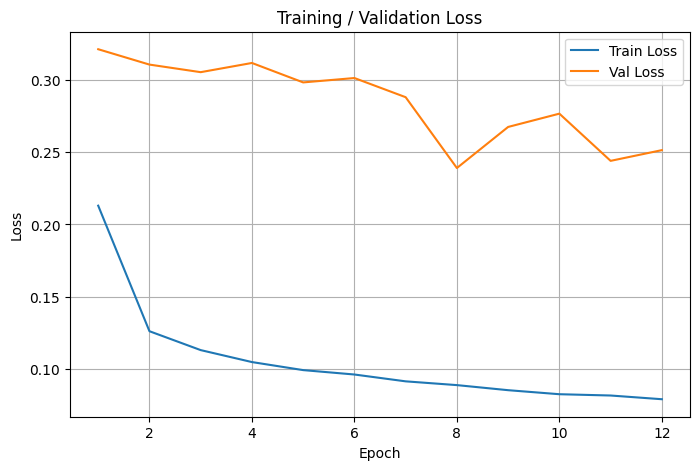

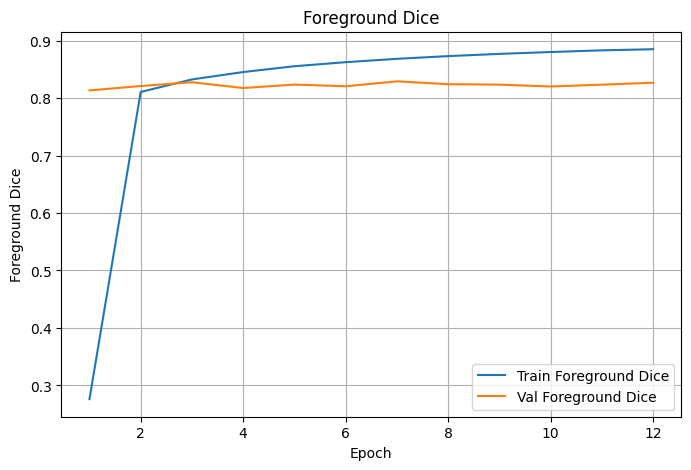

In [ ]:
# =========================
# 16. Training curves
# =========================
epochs = np.arange(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    epochs,
    history["val_loss"],
    label="Val Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history["train_fg_dice"],
    label="Train Foreground Dice"
)
plt.plot(
    epochs,
    history["val_fg_dice"],
    label="Val Foreground Dice"
)
plt.xlabel("Epoch")
plt.ylabel("Foreground Dice")
plt.title("Foreground Dice")
plt.grid(True)
plt.legend()
plt.show()

## 17. Final held-out test evaluation

In [ ]:
def load_best_checkpoint(model, path=BEST_CHECKPOINT):
    ckpt = torch.load(
        path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(ckpt["model_state_dict"])

    return ckpt


checkpoint_info = load_best_checkpoint(model)

print("Loaded:", BEST_CHECKPOINT)

Loaded: best_neuroseg_segformer_b2_4ch.pth


In [ ]:
import shutil

# Define the destination path in Google Drive
# Make sure '/content/drive/MyDrive/' exists and you have write permissions
destination_path = "/content/drive/MyDrive/best_neuroseg_segformer_b2_4ch.pth"

try:
    shutil.copyfile(BEST_CHECKPOINT, destination_path)
    print(f"Successfully copied {BEST_CHECKPOINT} to {destination_path}")
except Exception as e:
    print(f"Error copying file: {e}")
    print("Please ensure your Google Drive is mounted and the destination path is valid.")

Successfully copied best_neuroseg_segformer_b2_4ch.pth to /content/drive/MyDrive/best_neuroseg_segformer_b2_4ch.pth


In [ ]:
def dice_from_binary_counts(
    tp,
    fp,
    fn,
    eps=1e-8
):
    return 2 * tp / (
        2 * tp + fp + fn + eps
    )


def predict_probs_tta(model, images):
    """
    Flip-based test-time augmentation: averages softmax probabilities
    over the original image and its horizontal + vertical flips.
    Cheap and reliably improves boundary Dice at inference; use_tta=False
    below reproduces the old single-pass behavior for comparison.
    """
    with torch.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=USE_AMP
    ):
        probs = torch.softmax(model(images).logits, dim=1)

        flipped_h = torch.flip(images, dims=[3])
        probs = probs + torch.flip(
            torch.softmax(model(flipped_h).logits, dim=1), dims=[3]
        )

        flipped_v = torch.flip(images, dims=[2])
        probs = probs + torch.flip(
            torch.softmax(model(flipped_v).logits, dim=1), dims=[2]
        )

    return probs / 3.0


def evaluate_test_set(model, loader, use_tta=True):

    tp = np.zeros(
        NUM_CLASSES,
        dtype=np.float64
    )
    fp = np.zeros(
        NUM_CLASSES,
        dtype=np.float64
    )
    fn = np.zeros(
        NUM_CLASSES,
        dtype=np.float64
    )

    conf = np.zeros(
        (NUM_CLASSES, NUM_CLASSES),
        dtype=np.int64
    )

    volume_counts = {}
    n_slices = 0

    model.eval()

    with torch.no_grad():

        for images, masks, filenames in tqdm(
            loader,
            desc="FINAL TEST"
        ):
            images = images.to(
                device,
                non_blocking=True
            )
            masks = masks.to(
                device,
                non_blocking=True
            )

            if use_tta:
                probs = predict_probs_tta(model, images)
                if probs.shape[-2:] != masks.shape[-2:]:
                    probs = F.interpolate(
                        probs,
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    )
                preds = torch.argmax(probs, dim=1)
            else:
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=USE_AMP
                ):
                    logits = model(images).logits

                if logits.shape[-2:] != masks.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    )
                preds = torch.argmax(logits, dim=1)

            n_slices += images.shape[0]

            update_counts(
                tp, fp, fn,
                preds,
                masks
            )

            conf += confusion_matrix(
                masks.flatten().cpu().numpy(),
                preds.flatten().cpu().numpy(),
                labels=list(range(NUM_CLASSES))
            )

            for b, filename in enumerate(filenames):

                volume = get_volume_id(filename)

                p_fg = preds[b] > 0
                t_fg = masks[b] > 0

                values = volume_counts.setdefault(
                    volume,
                    [0, 0, 0]
                )

                values[0] += int(
                    (p_fg & t_fg).sum().item()
                )
                values[1] += int(
                    (p_fg & ~t_fg).sum().item()
                )
                values[2] += int(
                    (~p_fg & t_fg).sum().item()
                )

    metrics = metrics_from_counts(
        tp, fp, fn
    )

    patient_dice = np.asarray(
        [
            dice_from_binary_counts(
                v[0], v[1], v[2]
            )
            for v in volume_counts.values()
        ],
        dtype=np.float64
    )

    return {
        "num_test_slices": n_slices,
        "num_test_volumes": len(volume_counts),
        "per_class": metrics,
        "confusion_matrix": conf,
        "volume_ids": sorted(volume_counts.keys()),
        "patient_foreground_dice": patient_dice,
    }


test_results = evaluate_test_set(
    model,
    test_loader,
    use_tta=True
)


FINAL TEST:   0%|          | 0/1085 [00:00<?, ?it/s]

In [ ]:
# =========================
# 18. Final metrics
# =========================
m = test_results["per_class"]

print("=" * 72)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 72)

print("Slices:", test_results["num_test_slices"])
print("Volumes:", test_results["num_test_volumes"])

print("\nPer-class metrics:")

for c in range(NUM_CLASSES):
    print(
        f"Class {c}: "
        f"Dice={m['dice'][c]:.4f} | "
        f"IoU={m['iou'][c]:.4f} | "
        f"Recall={m['recall'][c]:.4f} | "
        f"Precision={m['precision'][c]:.4f}"
    )

print("\n>>> HEADLINE: COMPOSITE FOREGROUND / TUMOR-REGION <<<")
print(f"Dice:      {m['foreground_dice']:.4f}")
print(f"IoU:       {m['foreground_iou']:.4f}")
print(f"Recall:    {m['foreground_recall']:.4f}")
print(f"Precision: {m['foreground_precision']:.4f}")

print("\nMacro average (context only):")
print(f"Dice: {m['dice'].mean():.4f}")
print(f"IoU:  {m['iou'].mean():.4f}")

FINAL HELD-OUT TEST RESULTS
Slices: 8680
Volumes: 56

Per-class metrics:
Class 0: Dice=0.9983 | IoU=0.9966 | Recall=0.9977 | Precision=0.9989
Class 1: Dice=0.7858 | IoU=0.6472 | Recall=0.8190 | Precision=0.7552
Class 2: Dice=0.7695 | IoU=0.6254 | Recall=0.8913 | Precision=0.6770

>>> HEADLINE: COMPOSITE FOREGROUND / TUMOR-REGION <<<
Dice:      0.7816
IoU:       0.6414
Recall:    0.8364
Precision: 0.7335

Macro average (context only):
Dice: 0.8512
IoU:  0.7564


Patient/volume foreground Dice
Mean:    0.7531
Median:  0.8128
Std:     0.1928
Min:     0.0
Max:     0.9314


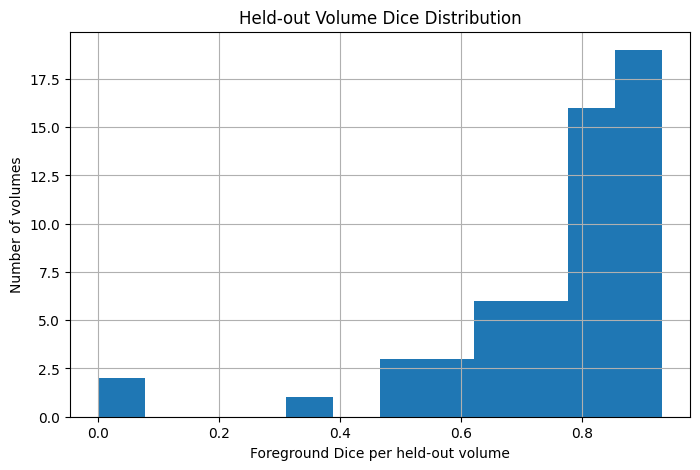

In [ ]:
# =========================
# 19. Patient/volume statistics
# =========================
patient_dice = test_results[
    "patient_foreground_dice"
]

print("Patient/volume foreground Dice")
print("Mean:   ", round(float(patient_dice.mean()), 4))
print("Median: ", round(float(np.median(patient_dice)), 4))
print("Std:    ", round(float(patient_dice.std(ddof=1)), 4))
print("Min:    ", round(float(patient_dice.min()), 4))
print("Max:    ", round(float(patient_dice.max()), 4))

plt.figure(figsize=(8, 5))
plt.hist(patient_dice, bins=12)
plt.xlabel("Foreground Dice per held-out volume")
plt.ylabel("Number of volumes")
plt.title("Held-out Volume Dice Distribution")
plt.grid(True)
plt.show()

In [ ]:
# =========================
# 20. Bootstrap 95% CI
# =========================
rng = np.random.RandomState(SEED)

n_boot = 2000
boot_means = np.empty(
    n_boot,
    dtype=np.float64
)

for i in range(n_boot):
    sample = rng.choice(
        patient_dice,
        size=len(patient_dice),
        replace=True
    )
    boot_means[i] = sample.mean()

ci_low, ci_high = np.percentile(
    boot_means,
    [2.5, 97.5]
)

print(
    f"Mean volume foreground Dice: "
    f"{patient_dice.mean():.4f}"
)
print(
    f"Bootstrap 95% CI: "
    f"[{ci_low:.4f}, {ci_high:.4f}]"
)

Mean volume foreground Dice: 0.7531
Bootstrap 95% CI: [0.6975, 0.7982]


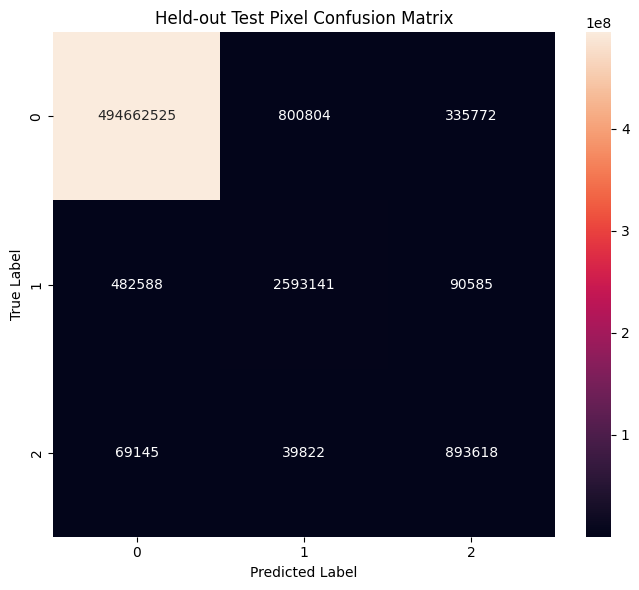

In [ ]:
# =========================
# 21. Confusion matrix
# =========================
plt.figure(figsize=(7, 6))

sns.heatmap(
    test_results["confusion_matrix"],
    annot=True,
    fmt="d",
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Held-out Test Pixel Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 22. Save final JSON report
# =========================
report = {
    "checkpoint": BEST_CHECKPOINT,
    "num_test_slices": test_results["num_test_slices"],
    "num_test_volumes": test_results["num_test_volumes"],
    "model": "SegFormer-B2",
    "input_channels": 4,
    "num_classes": NUM_CLASSES,
    "headline_composite_foreground": {
        "dice": float(m["foreground_dice"]),
        "iou": float(m["foreground_iou"]),
        "recall": float(m["foreground_recall"]),
        "precision": float(m["foreground_precision"]),
    },
    "per_class": {
        str(c): {
            "dice": float(m["dice"][c]),
            "iou": float(m["iou"][c]),
            "recall": float(m["recall"][c]),
            "precision": float(m["precision"][c]),
        }
        for c in range(NUM_CLASSES)
    },
    "patient_volume_foreground_dice": {
        "mean": float(patient_dice.mean()),
        "median": float(np.median(patient_dice)),
        "std": float(patient_dice.std(ddof=1)),
        "min": float(patient_dice.min()),
        "max": float(patient_dice.max()),
        "bootstrap_95ci": [
            float(ci_low),
            float(ci_high)
        ],
    },
}

with open(
    "neuroseg_final_test_results.json",
    "w"
) as f:
    json.dump(report, f, indent=2)

print("Saved: neuroseg_final_test_results.json")

Saved: neuroseg_final_test_results.json


## 23. Held-out test visualizations

In [ ]:
def display_test_examples(
    model,
    dataset,
    indices=(0, 1, 2, 3)
):
    model.eval()

    for idx in indices:

        image, true_mask, filename = dataset[idx]

        with torch.no_grad():
            logits = model(
                image.unsqueeze(0).to(device)
            ).logits

            logits = F.interpolate(
                logits,
                size=true_mask.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            pred = torch.argmax(
                logits,
                dim=1
            )[0].cpu()

        display_image = np.transpose(
            image[:3].numpy(),
            (1, 2, 0)
        )

        display_image = np.clip(
            display_image,
            0,
            1
        )

        overlay = display_image.copy()

        tumor = pred.numpy() > 0
        overlay[tumor] = (
            0.55 * overlay[tumor] + 0.45
        )

        fig, axes = plt.subplots(
            1,
            4,
            figsize=(16, 4)
        )

        axes[0].imshow(display_image)
        axes[0].set_title(
            f"Input\n{filename}"
        )

        axes[1].imshow(
            true_mask,
            cmap="viridis",
            vmin=0,
            vmax=2
        )
        axes[1].set_title("Ground Truth")

        axes[2].imshow(
            pred,
            cmap="viridis",
            vmin=0,
            vmax=2
        )
        axes[2].set_title("Prediction")

        axes[3].imshow(overlay)
        axes[3].set_title(
            "MRI + Predicted Foreground"
        )

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()


# Example:
# display_test_examples(
#     model,
#     test_dataset,
#     indices=(0, 10, 20, 30)
# )

## 24. Uncertainty / quantitative analysis helpers

The confidence produced by softmax is **uncalibrated confidence**, not a clinical probability.

In [ ]:
def prediction_uncertainty(model, image):

    model.eval()

    with torch.no_grad():

        logits = model(
            image.unsqueeze(0).to(device)
        ).logits

        logits = F.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        probs = torch.softmax(
            logits,
            dim=1
        )[0]

        pred = torch.argmax(
            probs,
            dim=0
        )

        confidence = probs.max(
            dim=0
        ).values

        entropy = -(
            probs
            * torch.log(
                probs.clamp_min(1e-8)
            )
        ).sum(dim=0)

    tumor = pred > 0

    mean_confidence = (
        float(
            confidence[tumor].mean().cpu()
        )
        if tumor.any()
        else 0.0
    )

    mean_entropy = (
        float(
            entropy[tumor].mean().cpu()
        )
        if tumor.any()
        else 0.0
    )

    return (
        pred.cpu(),
        confidence.cpu(),
        entropy.cpu(),
        mean_confidence,
        mean_entropy
    )

In [ ]:
def analyze_prediction(
    pred_mask,
    probs=None,
    confidence_map=None
):
    pred = np.asarray(pred_mask)
    tumor = pred > 0

    tumor_pixels = int(tumor.sum())

    area_percent = (
        100.0
        * tumor_pixels
        / pred.size
    )

    labels = measure.label(tumor)
    regions = measure.regionprops(labels)

    component_sizes = sorted(
        [r.area for r in regions],
        reverse=True
    )

    report = {
        "tumor_region_pixels": tumor_pixels,
        "affected_slice_area_percent": round(
            area_percent,
            3
        ),
        "connected_components": len(
            component_sizes
        ),
        "largest_component_pixels": (
            int(component_sizes[0])
            if component_sizes
            else 0
        ),
    }

    if (
        probs is not None
        and confidence_map is not None
        and tumor.any()
    ):
        report[
            "mean_tumor_confidence_uncalibrated"
        ] = float(
            confidence_map[tumor].mean()
        )

        entropy = -(
            probs
            * np.log(
                np.clip(
                    probs,
                    1e-8,
                    1
                )
            )
        ).sum(axis=0)

        report[
            "mean_tumor_entropy"
        ] = float(
            entropy[tumor].mean()
        )

    return report


print("Quantification helpers ready.")

Quantification helpers ready.
